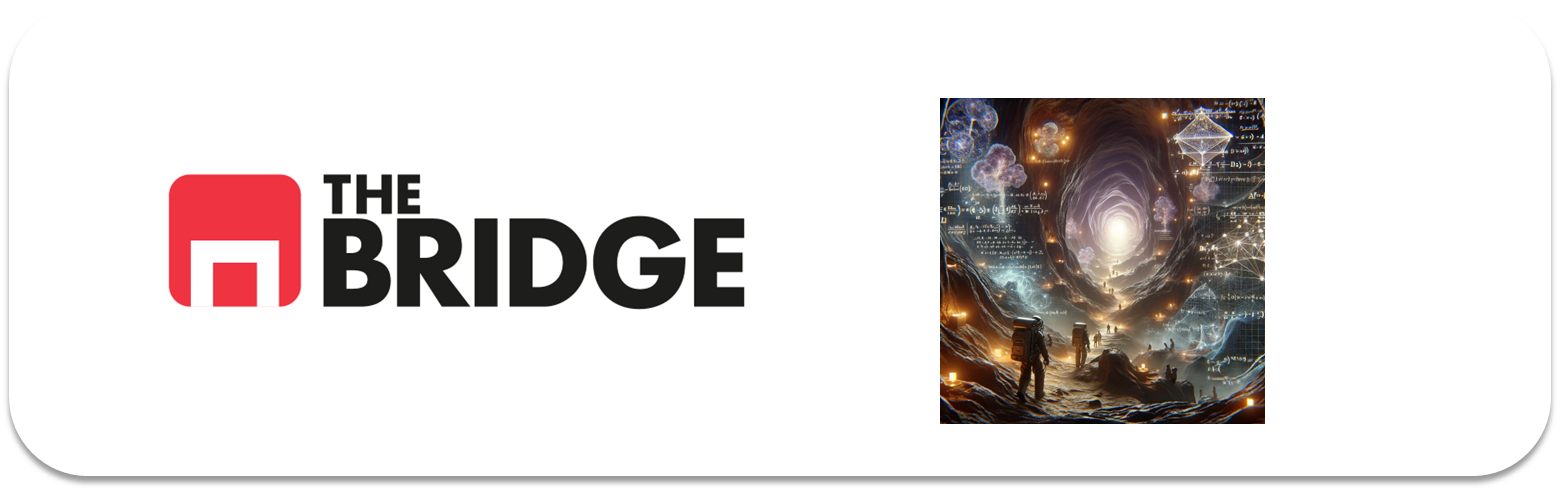

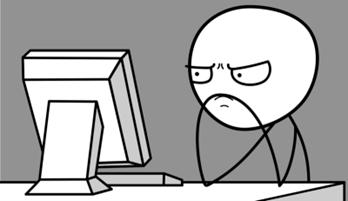

Para ejercitarte y afianzar lo aprendido sobre **Keras y DL**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Predecir eficiencia de gasolina

En este conjunto de ejercicios vamos a trabajar sobre el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) para construir un modelo DL para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Para la construcción del modelo vamos a utilizar Keras.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers # Capas

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Ejercicio 1

Carga los datos en un dataframe, utilizando como nombre de columnas los siguientes:

```python
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']
``` 


In [2]:
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin', 'nombre']
df = pd.read_csv("./data/Autos_data.txt", sep=r'\s+', header= None, names= column_names)

 Un SyntaxWarning en el código. El problema está en el uso de __'\s+'__ como separador — en versiones más recientes de Python, las secuencias de escape (\) no reconocidas en strings normales generan este aviso. La solución es simple: usar un raw string añadiendo una __r__ antes de las comillas:
 ```python
sep=r'\s+'
```
La __r__ convierte el string en un raw string, lo que le indica a Python que trate la barra invertida __\__ literalmente, sin intentar interpretarla como una secuencia de escape. Esto es lo correcto cuando se usan expresiones regulares.

In [3]:
df

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,nombre
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    object 
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   nombre        398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


### Ejercicio 2: Limpieza inicial

Echa un primer vistazo. Limpia columnas "raras". Deshazte de nulos (cuidado aquí), arregla el tipo de las features numéricas si fuera necesario. Haz una lista de las features categóricas que tuvieramos que convertir posteriormente. (Es antes del split pero no importa para este ejercicio)

In [5]:
def describe_df(df):
    data_dict = {}
    for columna in df.columns:
        data_type = "categorica" if df[columna].dtype == "object" else "numerica"
        valores_nulos = round(df[columna].isna().sum() / len(df) * 100, 1)
        valores_unicos = df[columna].nunique()
        cardinalidad_ptg = round(valores_unicos / len(df) * 100, 2)
        data_dict[columna] = {
            "data_type": data_type,
            "valores_nulos": valores_nulos,
            "valores_unicos": valores_unicos,
            "cardinalidad_ptg": cardinalidad_ptg
        }
    return pd.DataFrame(data_dict).T

In [6]:
describe_df(df)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
MPG,numerica,0.0,129,32.41
Cylinders,numerica,0.0,5,1.26
Displacement,numerica,0.0,82,20.6
Horsepower,categorica,0.0,94,23.62
Weight,numerica,0.0,351,88.19
Acceleration,numerica,0.0,95,23.87
Model Year,numerica,0.0,13,3.27
Origin,numerica,0.0,3,0.75
nombre,categorica,0.0,305,76.63


In [7]:
# Buscamos duplicados
print((df.duplicated()).sum())

0


In [8]:
df["Horsepower"].value_counts()

Horsepower
150.0    22
90.00    20
88.00    19
110.0    18
100.0    17
         ..
77.00     1
132.0     1
64.00     1
116.0     1
82.00     1
Name: count, Length: 94, dtype: int64

In [9]:
# Convertir Horsepower a float, 
# primero cambiar '?' por un Nan para luego rellenar con Imputacion mediante KNN
df.replace('?', np.nan, inplace=True)
df['Horsepower'] = df['Horsepower'].astype(float)

print(df['Horsepower'].dtype)  
print(df['Horsepower'].isnull().sum())

float64
6


In [10]:
# Imputacion mediante KNN
# from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
# Ajustar y transformar
df['Horsepower'] = imputer.fit_transform(df[['Horsepower']])

Ojo a los dobles corchetes df[['Horsepower']] — KNNImputer espera un __array 2D__, no una Serie.

In [11]:
print(df.isnull().sum())

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
nombre          0
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   nombre        398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


          Weight       MPG
Weight  1.000000 -0.831741
MPG    -0.831741  1.000000


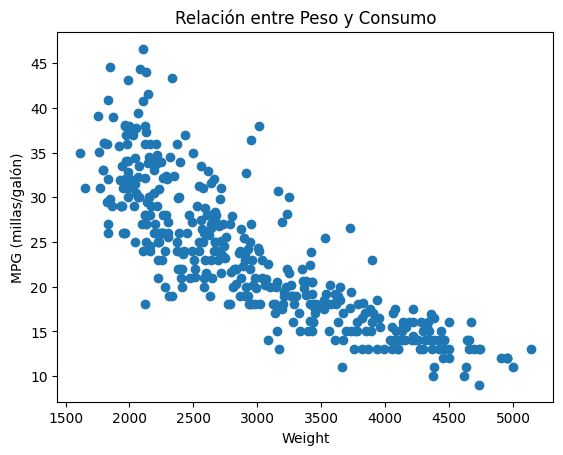

In [13]:
# Weight tiene una alta cardinalidad, comprobamos su correlación con el MPG
print(df[['Weight', 'MPG']].corr())
plt.scatter(df['Weight'], df['MPG'])
plt.xlabel('Weight')
plt.ylabel('MPG (millas/galón)')
plt.title('Relación entre Peso y Consumo')
plt.show()

In [14]:
# Voy a guardar los nombres de los coches en otro DataFrame
#  con el mismo número de índice que en el df original.
# Y quitar la columna nombre de df original

# Guardar los nombres en un DataFrame aparte con el mismo índice
df_nombres = df[['nombre']].copy()

# Verificar que tiene el mismo índice
print(df_nombres.head(3))

                      nombre
0  chevrolet chevelle malibu
1          buick skylark 320
2         plymouth satellite


In [15]:
# Borrar del df original
df = df.drop("nombre", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


### Ejercicio 3

Antes de seguir nos informan que las etiquetas de "origin" correspoden a  USA para el 1, Europa para el 2 y Japón para el 3. Convierte origin a esos valores porque queremos tener el literal. Luego haz directamente un one-hot encoding de esas variable.  

*NOTA: Realmente los one-hot-encoding se pueden hacer contra el dataset original desde el principio (no afectan unos a otros), si nos los hacemos es porque hasta que no se han analizado las variables puede que no tengamos claro que queremos hacer si una codificación ordinal, una vectorización (onehot) o bien queremos hacer otro cambio en la variable y esos vienen dados por la relación de la categórica con el target y por tanto sólo se pueden ver en el train. Pero si por lo que sea sabemos seguros que vamos a hacer vectorización no hay problema en hacerlo antes del split. Por otro lado, siempre conviene quedarse con una categoria unkown para valores que pueden llegar en el futuro antes de un recalibrado.*


In [16]:
mapeo = {1:"USA",
         2:"Europa",
         3:"Japón"}

df["Origin"] = df["Origin"].map(mapeo)

df["Origin"].value_counts()

Origin
USA       249
Japón      79
Europa     70
Name: count, dtype: int64

In [17]:
# from sklearn.preprocessing import OneHotEncoder
categorias = [["USA", "Europa", "Japón", "unknow"]]
encoder=OneHotEncoder(categories= categorias, sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df[["Origin"]])

df_encoded = pd.DataFrame(encoded, 
                          columns =encoder.get_feature_names_out(["Origin"]), index= df.index)

df = pd.concat([df, df_encoded], axis=1).drop(columns=['Origin'])

print(df.columns)


Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model Year', 'Origin_USA', 'Origin_Europa',
       'Origin_Japón', 'Origin_unknow'],
      dtype='object')


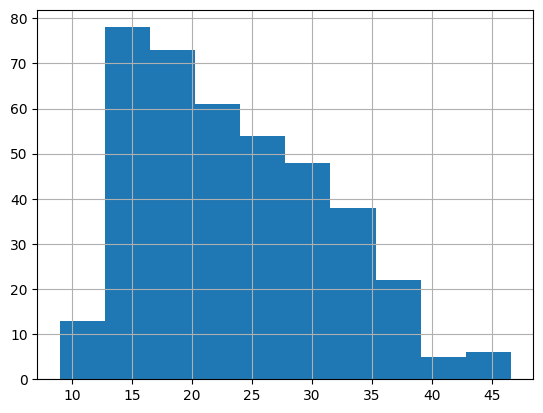

In [18]:
df.MPG.hist();

### Ejercicio 4

Divide los datos en train y test. Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo. Emplea una variable target para guardar el nombre de la columna target.

NOTA: El resultado tienen que ser dos datasets

In [19]:
# from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2,random_state=42)
print(train_set.shape)
print(test_set.shape)
target = "MPG"

(318, 11)
(80, 11)


### Ejercicio 5

Inspecciona los datos. Revisa rápidamente la distribución conjunta del dataset de entrenamiento mediante un grid de gráficos

              MPG   Cylinders  Displacement  Horsepower       Weight  \
count  318.000000  318.000000    318.000000  318.000000   318.000000   
mean    23.608176    5.430818    191.904088  103.302978  2969.015723   
std      7.930574    1.684947    102.983802   37.065574   840.617729   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000     98.500000   75.250000  2220.000000   
50%     22.450000    4.000000    148.500000   92.500000  2822.500000   
75%     29.725000    6.000000    259.500000  120.000000  3597.250000   
max     46.600000    8.000000    455.000000  225.000000  5140.000000   

       Acceleration  Model Year  Origin_USA  Origin_Europa  Origin_Japón  \
count    318.000000  318.000000  318.000000     318.000000    318.000000   
mean      15.639937   76.103774    0.616352       0.176101      0.207547   
std        2.763269    3.603177    0.487040       0.381506      0.406190   
min        8.000000   70.000000    0.000000    

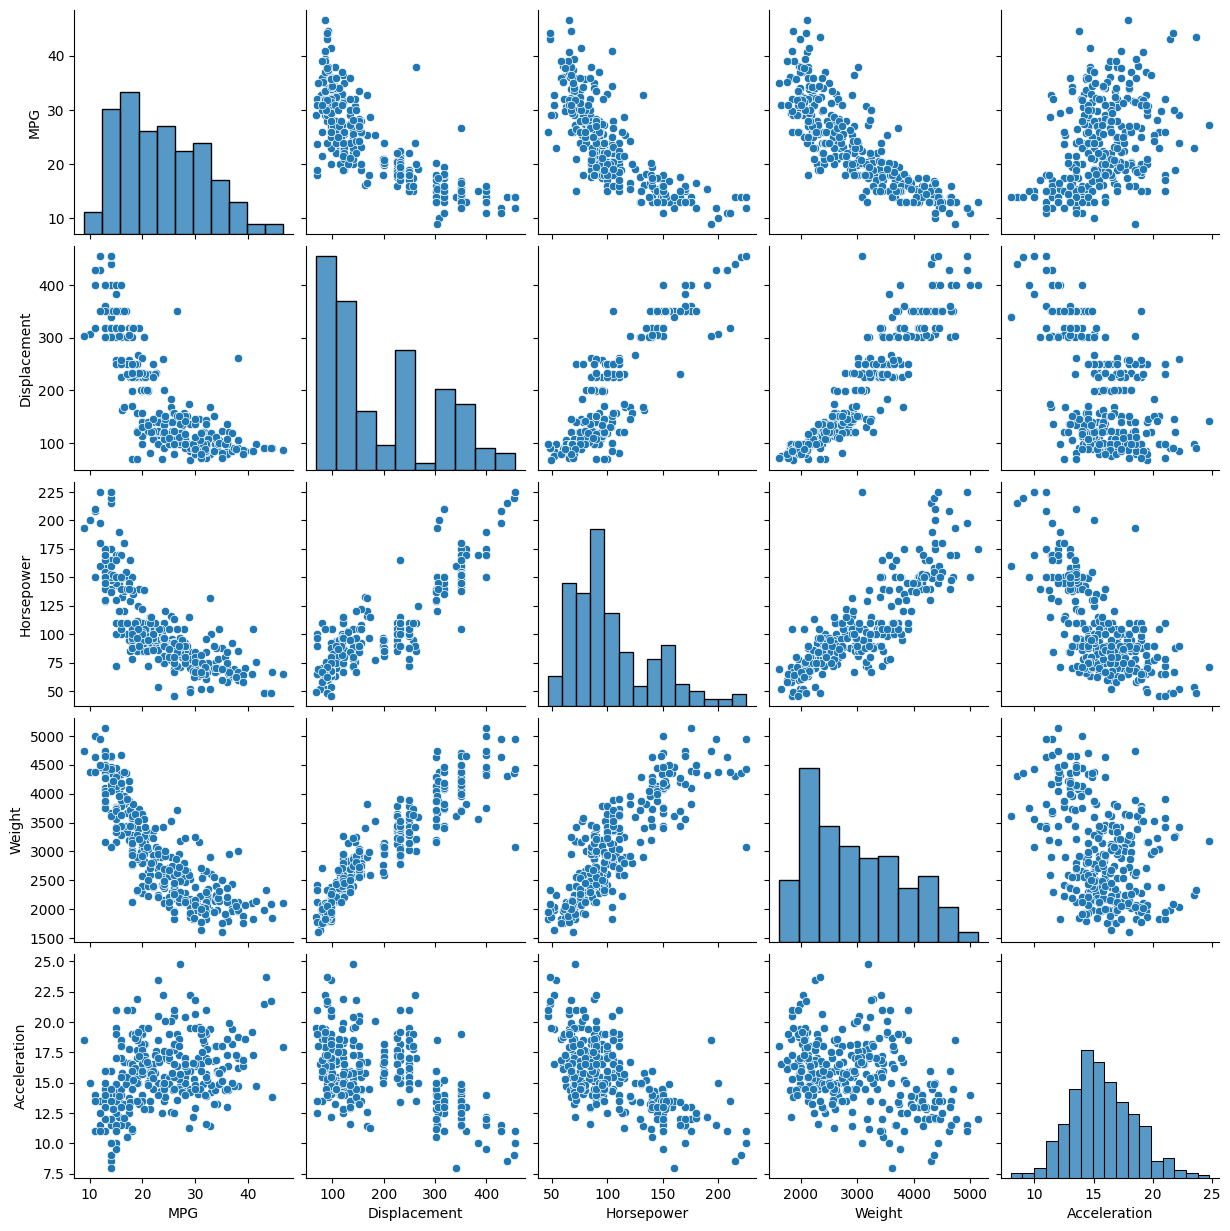

In [20]:
print(train_set.describe(), "\n")
sns.pairplot(train_set[["MPG","Displacement", "Horsepower", "Weight", "Acceleration"]]);

### Ejercicio 6 

Independientemente de lo que hayas encontrado en el análisis anterior, vamos a utilizar todas las features y antes las vamos a escalar. Estandardiza train y test.

In [21]:
train_set.columns

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model Year', 'Origin_USA', 'Origin_Europa',
       'Origin_Japón', 'Origin_unknow'],
      dtype='object')

In [22]:
# Columnas a escalar: 'Cylinders', 'Displacement', 'Horsepower', 'Weight','Acceleration', 'Model Year'
# No escalo el resto porque están entre 0 u 1.
# Voy a usar RobustScaler para el tratamiento de outlaiers.

# from sklearn.preprocessing import RobustScaler
col_escaled = ['Cylinders', 'Displacement', 'Horsepower', 'Weight','Acceleration', 'Model Year']
scaler = RobustScaler()
train_set[col_escaled] = scaler.fit_transform(train_set[col_escaled])

# Cuando tengas test_set, solo transform:
test_set[col_escaled] = scaler.transform(test_set[col_escaled])

In [23]:
train_set.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_USA,Origin_Europa,Origin_Japón,Origin_unknow
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.0
mean,23.608176,0.715409,0.269591,0.241407,0.106383,0.041158,0.017296,0.616352,0.176101,0.207547,0.0
std,7.930574,0.842474,0.639651,0.828281,0.610360,0.812726,0.600530,0.487040,0.381506,0.406190,0.0
min,9.000000,-0.500000,-0.500000,-1.039106,-0.878199,-2.205882,-1.000000,0.000000,0.000000,0.000000,0.0
25%,17.500000,0.000000,-0.310559,-0.385475,-0.437466,-0.470588,-0.500000,0.000000,0.000000,0.000000,0.0
50%,22.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0
75%,29.725000,1.000000,0.689441,0.614525,0.562534,0.529412,0.500000,1.000000,0.000000,0.000000,0.0
max,46.600000,2.000000,1.903727,2.960894,1.682701,2.735294,1.000000,1.000000,1.000000,1.000000,0.0


In [25]:
# Primero dividimos train_set y test_set en X e y
X_train = train_set.drop(target, axis=1)
y_train = train_set[target]
X_test = test_set.drop(target, axis=1)
y_test = test_set[target]

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(318, 10)
(318,)
(80, 10)
(80,)


## El modelo

### Ejercicio 7: Construye el modelo con Keras

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo. Es decir una MLP con dos capas ocultas.

Por tanto, tendrá tres capas. Una inicial con activación relu (usa el argumento `input_shape` para darle el número de features). Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres interesantes para las dos primeras capas (NOTA: En este caso partimos de pocas features, por lo que puede ser interesante poner 2 o 3 como mínimo el número de features para poder obtener unas pseudofeatures que intenten capturar las interrelaciones.)

Otros datos:

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

Utiliza una aproximación en prisma (mismo numero de unidades en las capas ocultas)

In [26]:
X_train.shape[1:]

(10,)

In [27]:
model = keras.models.Sequential([
    # No hace falta capa de flatten. No hay que aplanar ninguna imagen
    keras.layers.Dense(30, activation="relu",
                       input_shape=X_train.shape[1:]),
    keras.layers.Dense(30, activation="relu"),                   
    keras.layers.Dense(1) # Capa de salida con 1 neurona 
                          # y sin activación (lineal por defecto), apropiado para regresión
])
model.compile(loss="mean_squared_error",
              optimizer=tf.keras.optimizers.RMSprop(0.001),
              metrics = ["MeanAbsoluteError","MeanSquaredError"])



c:\Users\Arrate\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


```python
tf.keras.optimizers.RMSprop(0.001)
```
Es la ruta completa para acceder al optimizador RMSprop dentro de la librería TensorFlow/Keras.  
RMSprop en sí es un algoritmo de optimización que ajusta automáticamente el learning rate para cada parámetro durante el entrenamiento, lo que lo hace especialmente útil para problemas de regresión y redes recurrentes.  
(0.001) → se instancia esa clase con un learning rate de 0.001

### Ejercicio 8

Inspecciona el modelo usando el método `.summary` para imprimir una descripción simple del modelo

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291 (5.04 KB)

 Trainable params: 1,291 (5.04 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 9 Entrenar el modelo

Entrena el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

In [29]:
history = model.fit(X_train, y_train, epochs=1000,
                    validation_split=0.2)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - MeanAbsoluteError: 23.5318 - MeanSquaredError: 617.8420 - loss: 617.8420 - val_MeanAbsoluteError: 23.4435 - val_MeanSquaredError: 608.3921 - val_loss: 608.3921
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - MeanAbsoluteError: 23.1729 - MeanSquaredError: 603.4713 - loss: 603.4713 - val_MeanAbsoluteError: 23.1295 - val_MeanSquaredError: 595.5050 - val_loss: 595.5050
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 22.8395 - MeanSquaredError: 590.3516 - loss: 590.3516 - val_MeanAbsoluteError: 22.8043 - val_MeanSquaredError: 582.3490 - val_loss: 582.3490
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 22.4875 - MeanSquaredError: 576.6975 - loss: 576.6975 - val_MeanAbsoluteError: 22.4487 - val_MeanSquaredError: 568.1844 - val_loss: 568.1844
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 22.0977 - MeanSquaredError: 561.7002 - loss: 561.7002 - val_MeanAbsoluteError: 2

### Ejercicio 10

Visualiza el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`. Muestra la evolución del error en train y validation por un lado, y la evolución de la pérdida (loss), también train contra validation, en otra.

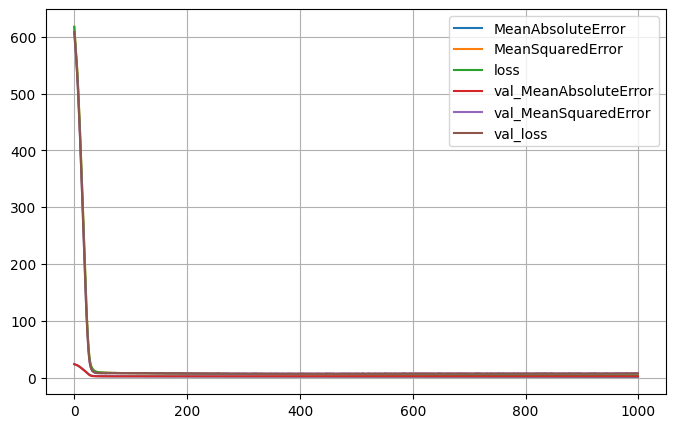

In [30]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
# plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

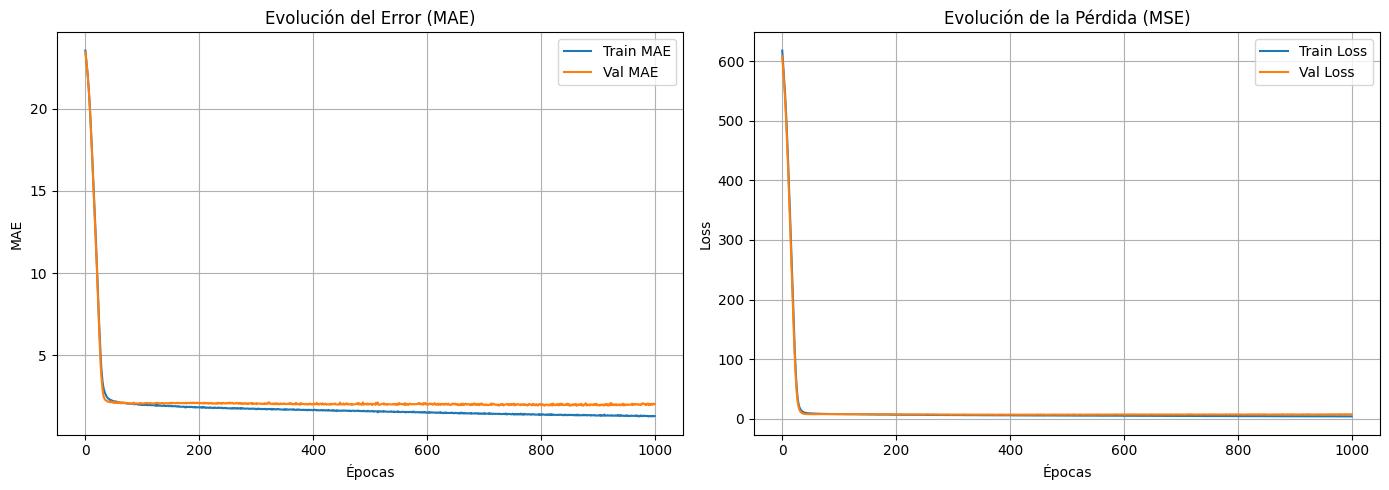

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error (MAE)
axes[0].plot(history.history['MeanAbsoluteError'], label='Train MAE')
axes[0].plot(history.history['val_MeanAbsoluteError'], label='Val MAE')
axes[0].set_title('Evolución del Error (MAE)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Evolución de la Pérdida (MSE)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

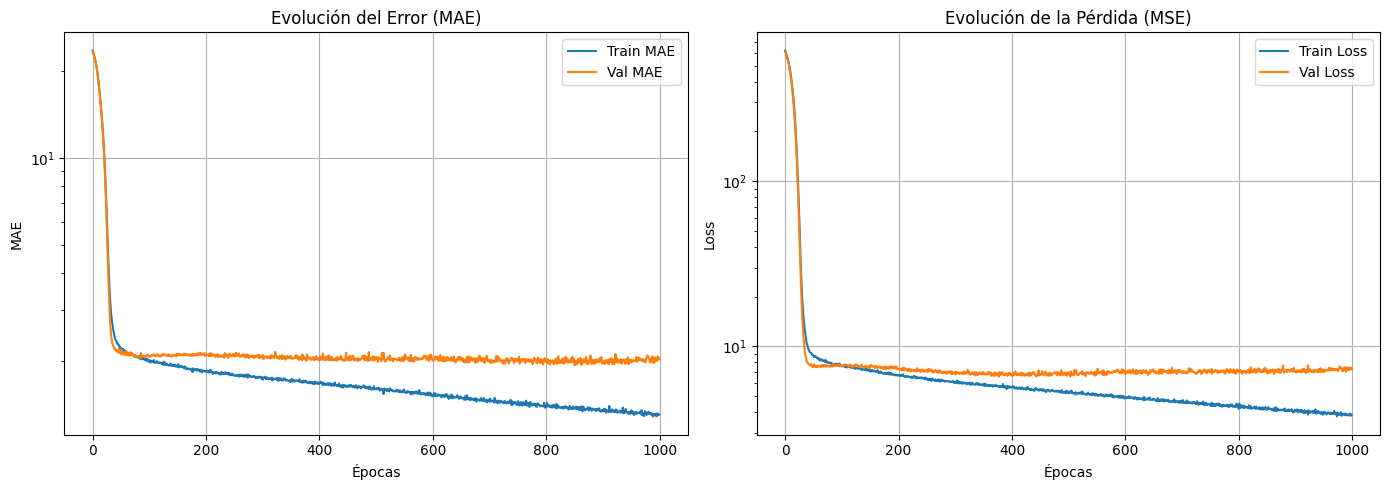

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error (MAE)
axes[0].plot(history.history['MeanAbsoluteError'], label='Train MAE')
axes[0].plot(history.history['val_MeanAbsoluteError'], label='Val MAE')
axes[0].set_title('Evolución del Error (MAE)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(True)
axes[0].set_yscale('log')

# Plot 2: Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Evolución de la Pérdida (MSE)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

```python
axes[1].set_yscale('log')
```
Cambia la escala del eje Y de lineal a logarítmica en el primer gráfico.
Escala lineal (por defecto): los valores se espacian de forma uniforme: 0, 100, 200, 300...
Escala logarítmica: los valores se espacian por potencias de 10: 0.1, 1, 10, 100, 1000...  
En este caso es útil porque el error baja de ~600 a ~10 muy rápido, lo que con escala lineal "aplasta" todo el resto de la curva y no se ve bien la evolución. Con escala log, tanto los valores grandes del principio como los pequeños del final se ven con detalle.

### Ejercicio 11

Comenta las gráficas anteriores.

Las gráficas revelan un overfitting claro:  
La curva de train (azul) sigue bajando continuamente hasta las 1000 épocas.  
La curva de val (naranja) se estanca ~época 100 e incluso sube ligeramente.  
El modelo está memorizando los datos de entrenamiento en lugar de generalizar.

### Ejercicio 12

Independientemente de lo comentado en 11, vamos a añadir un callback al entrenamiento. Para ello, construye el modelo otra vez y vuelve a compilarlo (si no lo haces, como ya sabes comenzará el entrenamiento donde lo dejó y no nos valdrá el callback para nada). Entrena el modelo con los mismos hiperparámetros del ejercicio 10 y pinta la gráfica de evolución de los errores e interprétalo (obten el MAE medio una vez "estabilizado" el entrenamiento).  

Para el earlystopping utiliza un margen de 20 epochs.

In [33]:
model_2 = keras.models.Sequential([
    # No hace falta capa de flatten. No hay que aplanar ninguna imagen
    keras.layers.Dense(30, activation="relu",
                       input_shape=X_train.shape[1:]),
    keras.layers.Dense(30, activation="relu"),                   
    keras.layers.Dense(1) # Capa de salida con 1 neurona 
                          # y sin activación (lineal por defecto), apropiado para regresión
])
model_2.compile(loss="mean_squared_error",
              optimizer=tf.keras.optimizers.RMSprop(0.001),
              metrics = ["MeanAbsoluteError","MeanSquaredError"])

early_stop = keras.callbacks.EarlyStopping(patience=20, 
                                                  restore_best_weights=True)

history_2 = model_2.fit(X_train, y_train, epochs=100,   # Me he equivocado he puesto 100
                    validation_split= 0.2,
                    callbacks=[early_stop])

Epoch 1/100


c:\Users\Arrate\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - MeanAbsoluteError: 23.2347 - MeanSquaredError: 604.4028 - loss: 604.4028 - val_MeanAbsoluteError: 23.1753 - val_MeanSquaredError: 595.4448 - val_loss: 595.4448
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - MeanAbsoluteError: 22.8915 - MeanSquaredError: 588.9550 - loss: 588.9550 - val_MeanAbsoluteError: 22.8701 - val_MeanSquaredError: 581.8616 - val_loss: 581.8616
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 22.5455 - MeanSquaredError: 574.1390 - loss: 574.1390 - val_MeanAbsoluteError: 22.5253 - val_MeanSquaredError: 567.2191 - val_loss: 567.2191
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - MeanAbsoluteError: 22.1623 - MeanSquaredError: 558.3155 - loss: 558.3155 - val_MeanAbsoluteError: 22.1522 - val_MeanSquaredError: 551.5503 - val_loss: 551.5503
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 21.7412 - MeanSquaredError: 541.1852 - loss: 541.1852 - val_MeanAbsoluteError: 21.7278 - val_Mean

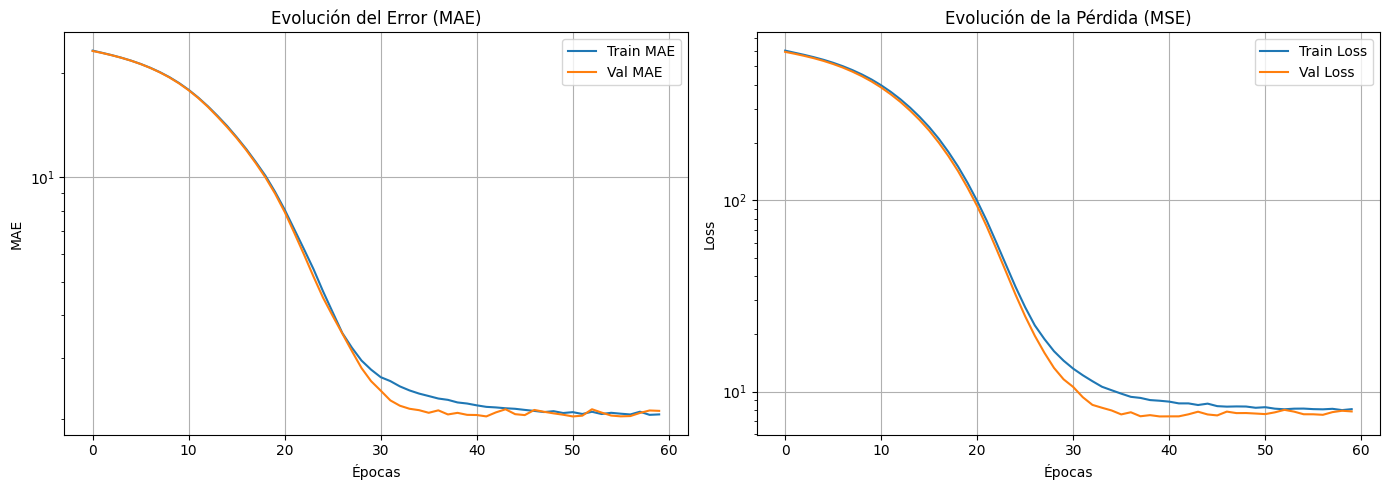

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error (MAE)
axes[0].plot(history_2.history['MeanAbsoluteError'], label='Train MAE')
axes[0].plot(history_2.history['val_MeanAbsoluteError'], label='Val MAE')
axes[0].set_title('Evolución del Error (MAE)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(True)
axes[0].set_yscale('log')

# Plot 2: Loss
axes[1].plot(history_2.history['loss'], label='Train Loss')
axes[1].plot(history_2.history['val_loss'], label='Val Loss')
axes[1].set_title('Evolución de la Pérdida (MSE)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()





In [44]:
print(np.mean(history.history['MeanAbsoluteError']))      # Media MAE train
print(np.mean(history.history['val_MeanAbsoluteError']))  # Media MAE validación

2.013968723773956
2.4120356748104097


In [45]:
print(np.mean(history_2.history['MeanAbsoluteError']))      # Media MAE train
print(np.mean(history_2.history['val_MeanAbsoluteError']))  # Media MAE validación

7.710032924016317
7.618685742219289


Interpreta el gráfico

In [46]:
model_3 = keras.models.Sequential([
    # No hace falta capa de flatten. No hay que aplanar ninguna imagen
    keras.layers.Dense(30, activation="relu",
                       input_shape=X_train.shape[1:]),
    keras.layers.Dense(30, activation="relu"),                   
    keras.layers.Dense(1) # Capa de salida con 1 neurona 
                          # y sin activación (lineal por defecto), apropiado para regresión
])
model_3.compile(loss="mean_squared_error",
              optimizer=tf.keras.optimizers.RMSprop(0.001),
              metrics = ["MeanAbsoluteError","MeanSquaredError"])

early_stop = keras.callbacks.EarlyStopping(patience=20, 
                                                  restore_best_weights=True)

history_3 = model_3.fit(X_train, y_train, epochs=1000,   
                    validation_split= 0.2,
                    callbacks=[early_stop])

Epoch 1/1000


c:\Users\Arrate\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - MeanAbsoluteError: 23.1478 - MeanSquaredError: 600.5246 - loss: 600.5246 - val_MeanAbsoluteError: 23.0397 - val_MeanSquaredError: 589.0929 - val_loss: 589.0929
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 22.7291 - MeanSquaredError: 581.3795 - loss: 581.3795 - val_MeanAbsoluteError: 22.6481 - val_MeanSquaredError: 571.4660 - val_loss: 571.4660
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 22.3119 - MeanSquaredError: 563.2484 - loss: 563.2484 - val_MeanAbsoluteError: 22.2267 - val_MeanSquaredError: 553.0961 - val_loss: 553.0961
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - MeanAbsoluteError: 21.8705 - MeanSquaredError: 544.0255 - loss: 544.0255 - val_MeanAbsoluteError: 21.7691 - val_MeanSquaredError: 533.4925 - val_loss: 533.4925
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 21.3763 - MeanSquaredError: 523.5115 - loss: 523.5115 - val_MeanAbsoluteError: 21.2725 - val_

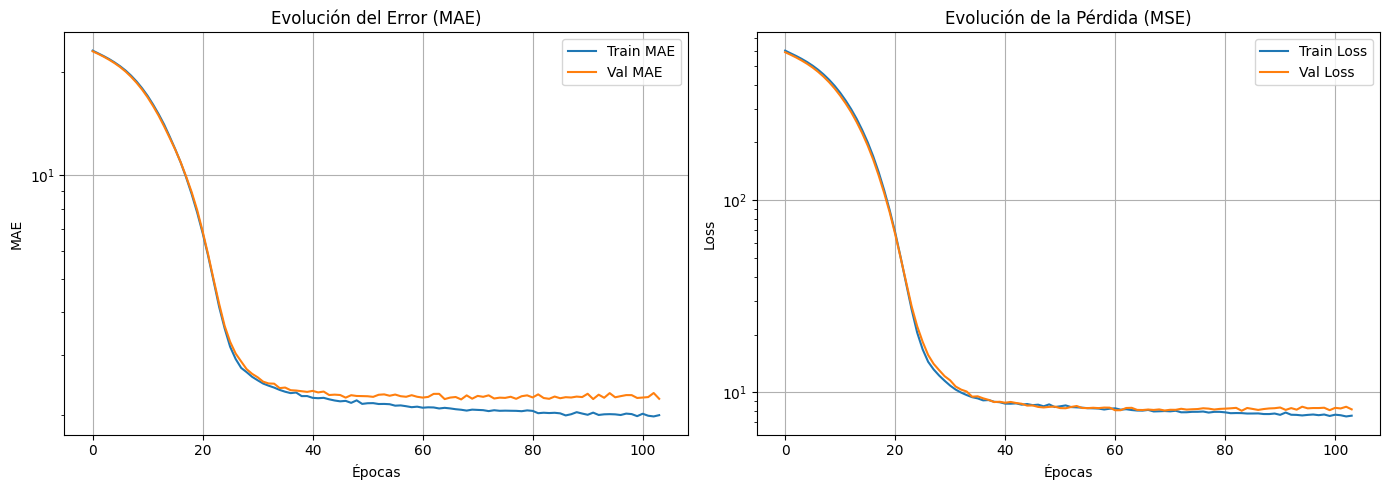

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error (MAE)
axes[0].plot(history_3.history['MeanAbsoluteError'], label='Train MAE')
axes[0].plot(history_3.history['val_MeanAbsoluteError'], label='Val MAE')
axes[0].set_title('Evolución del Error (MAE)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(True)
axes[0].set_yscale('log')

# Plot 2: Loss
axes[1].plot(history_3.history['loss'], label='Train Loss')
axes[1].plot(history_3.history['val_loss'], label='Val Loss')
axes[1].set_title('Evolución de la Pérdida (MSE)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


In [48]:
print(np.mean(history_3.history['MeanAbsoluteError']))      # Media MAE train
print(np.mean(history_3.history['val_MeanAbsoluteError']))  # Media MAE validación

5.0927769644902305
5.203334274200293


In [49]:
# Comparamos el mínimo de validación
print(np.min(history_3.history['val_MeanAbsoluteError']))   # Nuevo (con EarlyStopping)
print(np.min(history.history['val_MeanAbsoluteError']))  # Anterior

2.2182276248931885
1.9264582395553589


El modelo anterior gana en val MAE mínimo (1.92 vs 2.21), aunque con overfitting.
Esto puede significar varias cosas:  
El modelo con EarlyStopping para demasiado pronto — se puede probar a aumentar el __patience__.  
O que el modelo necesita más capacidad para aprender bien sin overfitting. Probar con más __neuronas__.  
También puede ayudar combinar EarlyStopping con __Dropout__(apaga neuronas aleatoriamente) para regularizar sin parar tan pronto.


El modelo es mejor porque no hay sobreajuste, sin embargo habría que mejorarlo.

### Ejercicio 13

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [50]:
loss, mae, mse = model_3.evaluate(X_test, y_test)  # Loss, MAE, MSE
print(f"Loss (MSE):  {loss:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"MSE:         {mse:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - MeanAbsoluteError: 1.8182 - MeanSquaredError: 5.7353 - loss: 5.7353 
Loss (MSE):  5.7353
MAE:         1.8182
MSE:         5.7353


El MAE en test es incluso mejor que en validación, lo cual es una señal muy positiva — el modelo está generalizando bien y no hay overfitting relevante.

### Ejercicio 14

Dibuja en un scatter plot las predicciones de test vs sus true labels.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


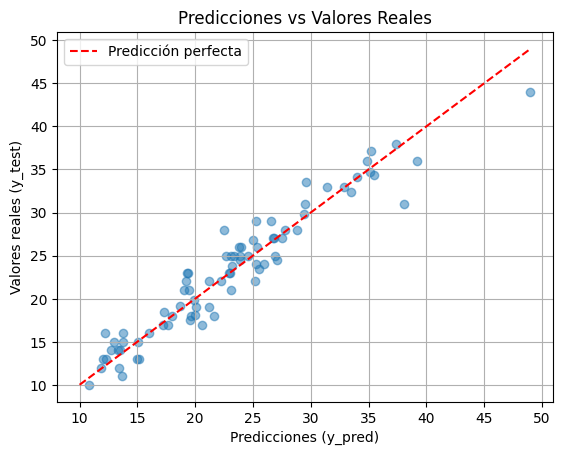

In [52]:
y_pred = model.predict(X_test)
y_test

plt.scatter(y_pred, y_test,alpha=0.5)
# Línea diagonal perfecta
min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')
plt.xlabel('Predicciones (y_pred)')
plt.ylabel('Valores reales (y_test)')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.grid(True)
plt.show()

Los puntos siguen bastante bien la diagonal roja, lo que confirma que el modelo funciona bien.
Observaciones:
 Zona central (15-35) — predicciones muy precisas, los puntos están pegados a la diagonal  
 Zona baja (10-15) — también bastante bien  
 Zona alta (>35) — algo más de dispersión, el modelo tiene más dificultad con los valores extremos. Esto es habitual, ya que suele haber menos ejemplos de entrenamiento en los extremos.  
En general es un resultado consistente con el MAE de 1.82 del evaluate — los errores son pequeños y distribuidos a ambos lados de la diagonal, sin ningún sesgo sistemático claro (como que el modelo subestime o sobreestime siempre).